<a href="https://colab.research.google.com/github/aadi8ya/data_visualization-on-ipl-dataset/blob/main/IPL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv('/content/IPL.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [31]:
df.shape

(74, 20)

In [32]:
df.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


Which team won the most matches?

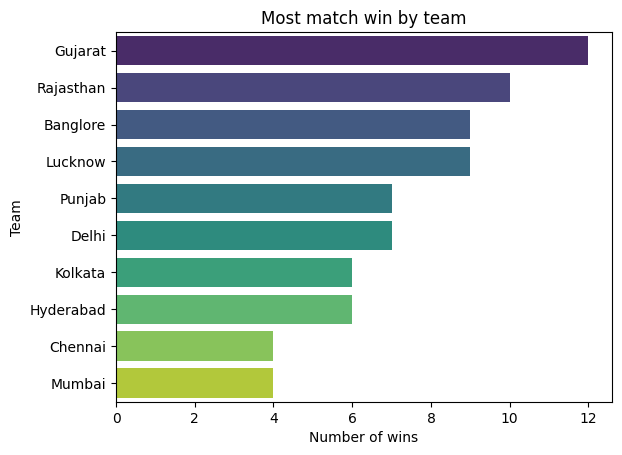

In [33]:
match_wins=df['match_winner'].value_counts()
sns.barplot(y=match_wins.index,x=match_wins.values,palette='viridis')
plt.title("Most match win by team")
plt.xlabel("Number of wins")
plt.ylabel("Team")
plt.show()

2. Toss Decision Trends

Text(0.5, 1.0, 'Toss Decision')

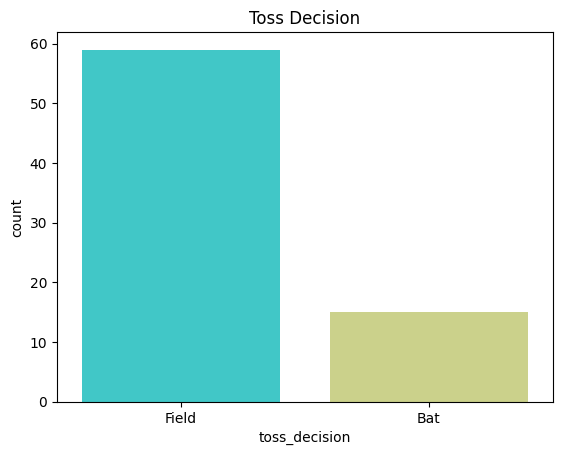

In [34]:
df['toss_decision'].value_counts()
sns.countplot(x=df['toss_decision'],palette='rainbow')
plt.title("Toss Decision")

3. toss winnner vs match winner

In [35]:
count=df[df['toss_winner']==df['match_winner']]['match_id'].count()
percentage = (count*100)/df.shape[0]
percentage.round(2)

np.float64(48.65)

4. how do teams win ?(runs vs wickets)

Text(0.5, 1.0, 'Won by')

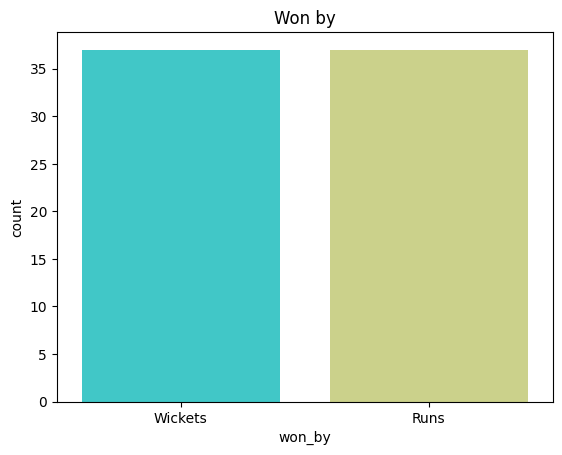

In [39]:
sns.countplot(x=df['won_by'],palette='rainbow')
plt.title("Won by")

most player of the match awards

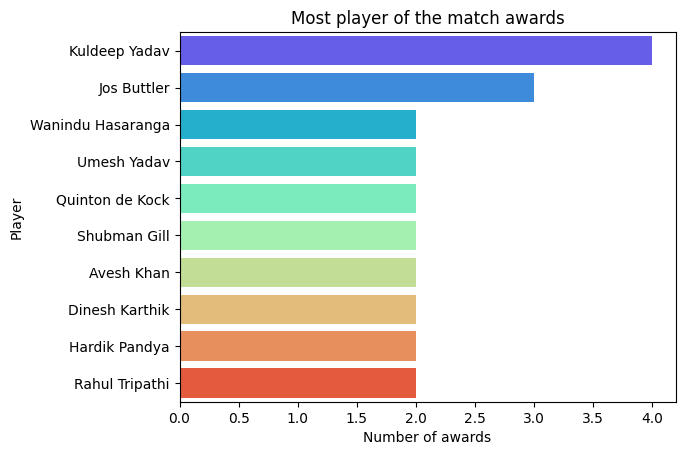

In [45]:
count=df['player_of_the_match'].value_counts().head(10)
sns.barplot(x=count.values,y=count.index,palette='rainbow')
plt.title("Most player of the match awards")
plt.xlabel("Number of awards")
plt.ylabel("Player")
plt.show()

 top scorers

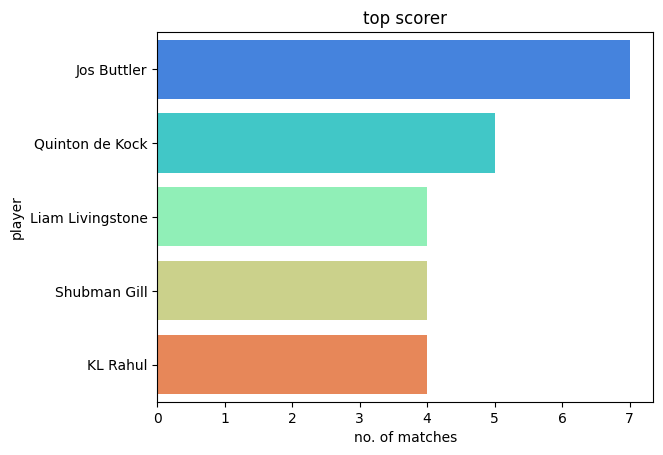

In [51]:
top=df['top_scorer'].value_counts().head(5)
sns.barplot(x=top.values,y=top.index,palette='rainbow')
plt.title("top scorer")
plt.xlabel("no. of matches")
plt.ylabel("player")
plt.show()

Top 2 scorer in all matches

<Axes: xlabel='top_scorer'>

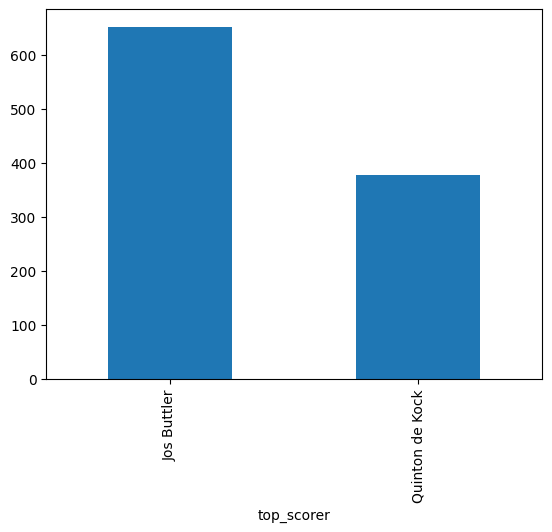

In [53]:
high=df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high.plot(kind='bar')

10 best bowling figures

<Axes: xlabel='best_bowling'>

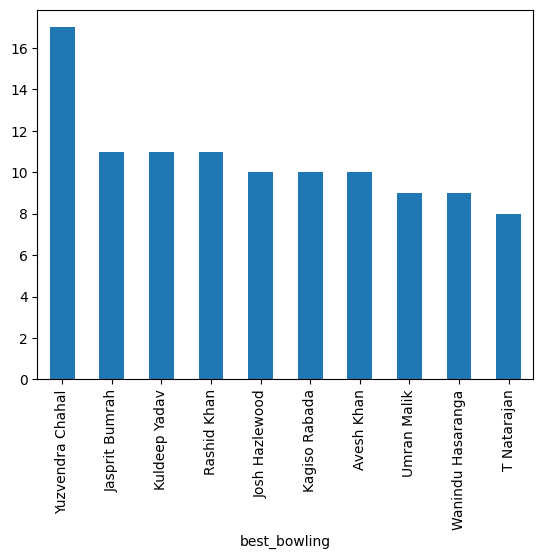

In [63]:
df['highest_wickets']=df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['highest_wickets']=df['highest_wickets'].astype(int)
top_bowlers=df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind='bar')

most matches played by venue

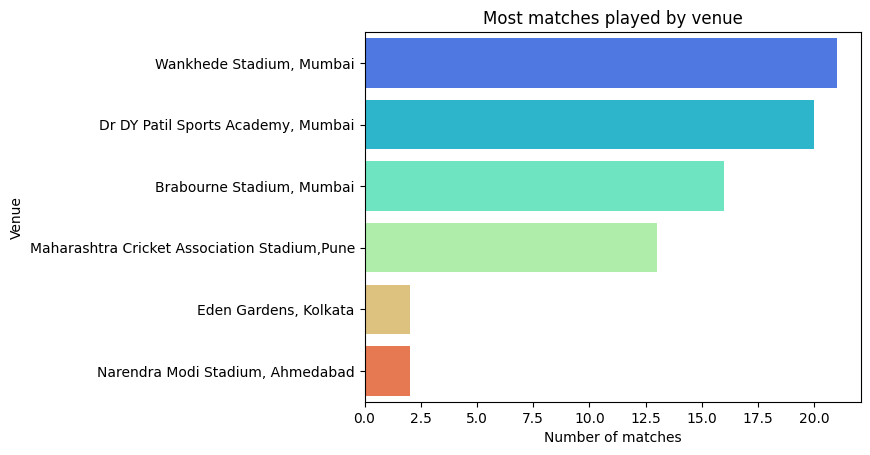

In [67]:
venue_count=df['venue'].value_counts()
sns.barplot(x=venue_count.values,y=venue_count.index,palette='rainbow')
plt.title("Most matches played by venue")
plt.xlabel("Number of matches")
plt.ylabel("Venue")
plt.show()

who won the highest margin by runs?

In [69]:
df[df['won_by']=='Runs'].sort_values(by='margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


which player had the highest individual score?

In [71]:
df[df['highscore']==df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


which bowler has the best bowling figure

In [74]:
df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
